# 05 - Explaining the Model with SHAP

**Two jobs in one notebook:**

1. **Explainability (the deliverable):** show *why* the Random Forest flags a flow as malicious, in a way a SOC analyst can act on.
2. **Leakage diagnosis:** see which features the model relies on. If a capture-specific feature like destination port dominates, that helps explain the leakage we found in 04b.

What is SHAP?  For any single prediction, SHAP fairly splits the credit among the features: each feature gets a number (a SHAP value). A **positive** value pushed the prediction **towards 'malicious'**; a **negative** value pushed towards 'benign'. Add them all up and you get that flow's score. Averaging the size of these values across many flows tells us which features matter most overall.

## Setup and load the trained Random Forest

We explain the Random Forest saved in notebook 03 (the winner on the random split).

In [1]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt

import shap

PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "outputs", "processed")
MODELS_DIR = os.path.join(PROJECT_ROOT, "outputs", "models")
FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
os.makedirs(FIG_DIR, exist_ok=True)

data = joblib.load(os.path.join(PROCESSED_DIR, "train_test_data.joblib"))
X_test = data["X_test"]
y_test = data["y_test"]
feature_names = list(data["feature_names"])

rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.joblib"))
print("Loaded Random Forest and test set:", X_test.shape)

Loaded Random Forest and test set: (149333, 22)


## Compute SHAP values on a sample

SHAP on every test row would be slow, so we take a random sample (2,000 flows) - plenty for stable explanations. `TreeExplainer` is the fast SHAP method built for tree models like Random Forest.

In [2]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_test.shape[0], size=min(2000, X_test.shape[0]), replace=False)
X_sample = X_test[sample_idx]
y_sample = y_test[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    sv = shap_values[1]
elif getattr(shap_values, "ndim", 2) == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

print("SHAP values ready:", sv.shape, "(rows x features)")

SHAP values ready: (2000, 22) (rows x features)


## Global view 1 - which features matter most (bar chart)

This ranks features by the **average size** of their SHAP value: how much, on average, each feature moves the decision. Top of the chart = most influential overall.

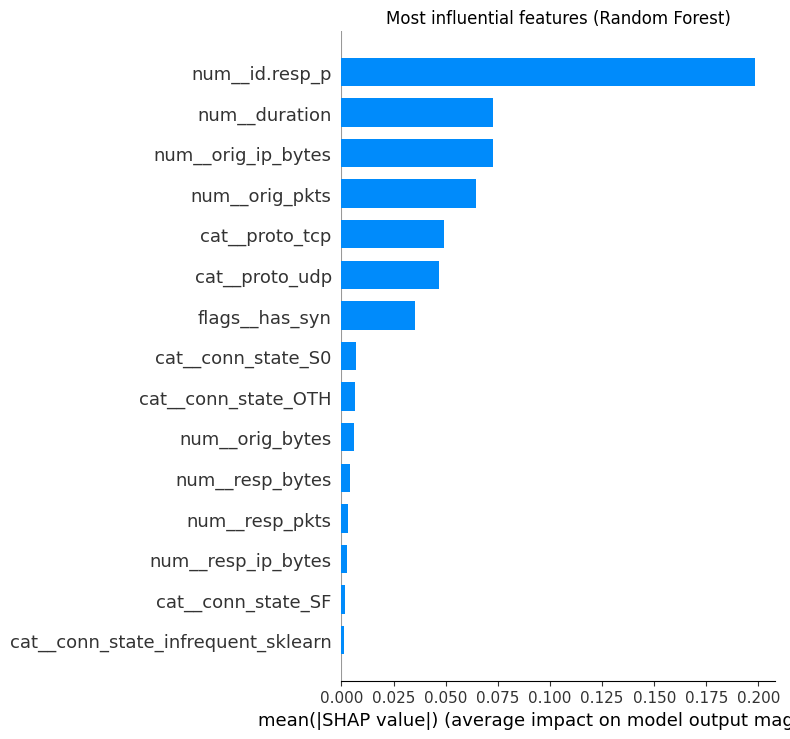

Top 15 features by mean |SHAP|:
  num__id.resp_p                      0.1982
  num__duration                       0.0728
  num__orig_ip_bytes                  0.0728
  num__orig_pkts                      0.0647
  cat__proto_tcp                      0.0491
  cat__proto_udp                      0.0469
  flags__has_syn                      0.0351
  cat__conn_state_S0                  0.0072
  cat__conn_state_OTH                 0.0062
  num__orig_bytes                     0.0059
  num__resp_bytes                     0.0042
  num__resp_pkts                      0.0032
  num__resp_ip_bytes                  0.0029
  cat__conn_state_SF                  0.0015
  cat__conn_state_infrequent_sklearn  0.0012


In [3]:
shap.summary_plot(sv, X_sample, feature_names=feature_names,
                  plot_type="bar", show=False, max_display=15)
plt.title("Most influential features (Random Forest)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "shap_importance_bar.png"), dpi=150, bbox_inches="tight")
plt.show()

# Print the feature-importance ranking as a table
mean_abs = np.abs(sv).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
print("Top 15 features by mean |SHAP|:")
for i in order[:15]:
    print(f"  {feature_names[i]:35s} {mean_abs[i]:.4f}")

## Global view 2 - direction of effect (beeswarm)

Each dot is one flow. Red = a high value of that feature, blue = low. Dots to the **right** pushed towards malicious, to the **left** towards benign. This shows not just *which* features matter but *how*: e.g. 'high packet counts push towards malicious'.

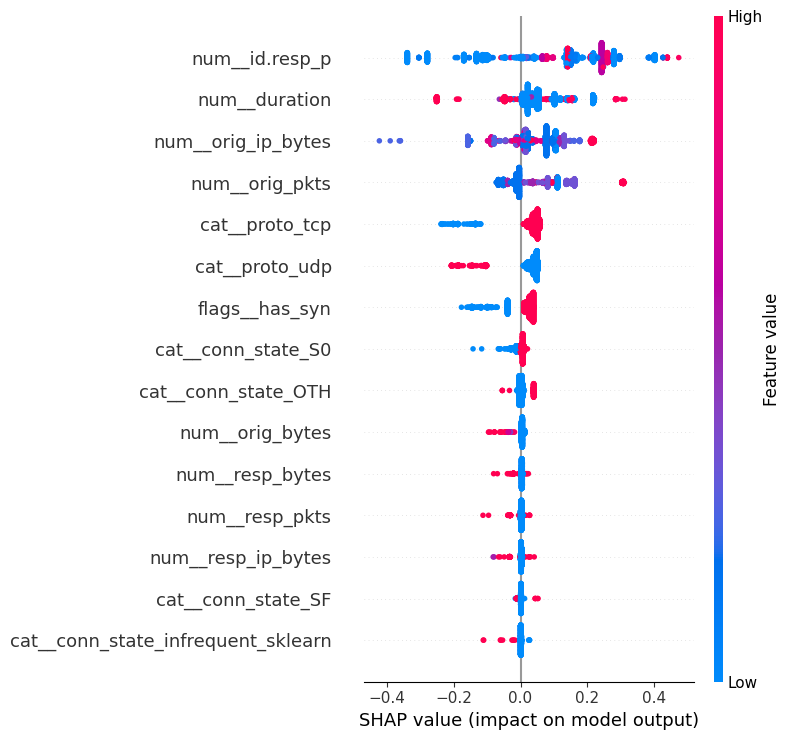

In [4]:
shap.summary_plot(sv, X_sample, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "shap_beeswarm.png"), dpi=150, bbox_inches="tight")
plt.show()

## Local view - explaining ONE alert for a SOC analyst

This is the SOC use-case: take a single flow the model flagged as malicious and list the features that drove that decision. This is the kind of plain explanation an analyst needs next to an alert.

In [5]:
proba = rf.predict_proba(X_sample)[:, 1]
malicious_rows = np.where(y_sample == 1)[0]
pick = malicious_rows[np.argmax(proba[malicious_rows])]   # most-confident malicious flow

contrib = sv[pick]
order = np.argsort(np.abs(contrib))[::-1]

print(f"Flow #{pick}: model probability malicious = {proba[pick]:.3f}\n")
print("Top features driving THIS alert (+ = towards malicious, - = towards benign):")
for i in order[:10]:
    direction = "->malicious" if contrib[i] > 0 else "->benign"
    print(f"  {feature_names[i]:35s} {contrib[i]:+.4f}  {direction}")

Flow #0: model probability malicious = 1.000

Top features driving THIS alert (+ = towards malicious, - = towards benign):
  num__duration                       +0.2170  ->malicious
  num__orig_pkts                      +0.1616  ->malicious
  num__id.resp_p                      -0.1319  ->benign
  num__orig_ip_bytes                  +0.1305  ->malicious
  cat__proto_udp                      +0.0389  ->malicious
  cat__proto_tcp                      +0.0370  ->malicious
  flags__has_syn                      +0.0265  ->malicious
  num__orig_bytes                     +0.0053  ->malicious
  num__resp_bytes                     +0.0046  ->malicious
  cat__conn_state_S0                  +0.0034  ->malicious
